# Setup

In [42]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


# Token embedding

In [43]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:

        return self.embedding(input_ids)

# Sinosoidal positional encoding

### Focus: Positional Encoding
In this project, we analyze how positional encoding allows Transformers to understand sequence order.

**Key idea:** Transformers process tokens in parallel and have no inherent notion of order. Positional encoding injects order information into token embeddings so attention can learn relationships.


In [44]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()

        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]])

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (batch_size, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

**Insight:** Positional encoding does not directly model relationships.  
It enables attention to learn relationships by providing order information.

**Core operation:** `x = token_embedding + positional_encoding`


### Mini Experiment: Without Positional Encoding

We remove positional encoding to observe how the model loses sequence order information.


In [45]:
class NoPositionalEncoding(nn.Module):
    def forward(self, x):
        return x

vocab_size = 100
d_model = 16

input_ids = torch.tensor([
    [1, 5, 8, 2, 9, 4],
    [3, 7, 1, 0, 6, 2]
])

# create embedding block w/o positional encoding
no_pe_block = InputEmbeddingBlock(vocab_size, d_model)
no_pe_block.position_encoding = NoPositionalEncoding()

out_no_pe = no_pe_block(input_ids)

print("Output without positional encoding (first token):")
print(out_no_pe[0, 0])

Output without positional encoding (first token):
tensor([ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806,
         1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,  0.8599],
       grad_fn=<SelectBackward0>)


# Combining token embedding + positional encoding

In [46]:
class InputEmbeddingBlock(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, max_len: int = 512):
        super().__init__()
        self.token_embedding = TokenEmbedding(vocab_size, d_model)
        self.position_encoding = SinusoidalPositionalEncoding(d_model, max_len)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        x = self.token_embedding(input_ids)
        x = self.position_encoding(x)
        return x

# Create a small model and sample input

In [47]:
vocab_size = 100
d_model = 16
max_len = 32

model = InputEmbeddingBlock(vocab_size, d_model, max_len).to(device)

input_ids = torch.tensor([
    [1, 5, 8, 2, 9, 4],
    [3, 7, 1, 0, 6, 2]
], device=device)

print("input_ids shape:", input_ids.shape)
print(input_ids)

input_ids shape: torch.Size([2, 6])
tensor([[1, 5, 8, 2, 9, 4],
        [3, 7, 1, 0, 6, 2]])


# Run the model

In [48]:
output = model(input_ids)

print("output shape:", output.shape)
print(output)

output shape: torch.Size([2, 6, 16])
tensor([[[ 0.8866,  0.1389, -0.2726,  1.9804, -0.1753,  0.8772,  0.7414,
           1.3540, -0.5346,  1.6454, -2.9891,  1.1837, -0.4727,  0.0412,
          -1.5124,  2.5068],
         [ 1.7128,  0.0175,  1.5510,  0.0446,  0.8679,  2.6172,  0.1132,
           1.2023,  0.3402,  0.0466,  1.5766,  2.8697, -1.0629,  0.7727,
           0.2504,  2.1618],
         [-0.0878, -0.7642,  0.8088,  1.9343, -1.3018,  0.7396, -0.4223,
           0.9318, -0.8829,  1.6438,  0.7655, -1.0203, -0.6720,  0.0808,
           1.2127, -0.3463],
         [-0.7969, -1.6285,  1.0321,  0.1435,  0.1564,  0.9366,  1.7508,
           2.0616, -0.1519, -0.2384,  0.5237,  0.8489,  0.1407,  2.2251,
          -0.7633,  1.9184],
         [-1.2400,  1.0650,  0.3851, -2.6140,  1.4728,  0.9984,  1.3578,
           3.9115,  1.9778,  0.4456, -1.2903,  2.0695, -0.4522,  2.3635,
          -2.4207,  0.9169],
         [-0.8519,  0.1822,  1.0830,  0.7017, -0.4212,  1.7683,  0.6340,
           0.14

# Inspect token embeddings only

In [49]:
token_emb = model.token_embedding(input_ids)

print("Token embedding shape:", token_emb.shape)
print("\nToken embedding for first token in first sentence:")
print(token_emb[0, 0])

Token embedding shape: torch.Size([2, 6, 16])

Token embedding for first token in first sentence:
tensor([ 0.8866, -0.8611, -0.2726,  0.9804, -0.1753, -0.1228,  0.7414,  0.3540,
        -0.5346,  0.6454, -2.9891,  0.1837, -0.4727, -0.9588, -1.5124,  1.5068],
       grad_fn=<SelectBackward0>)


## Inspect positional encodings

In [50]:
print("Positional encoding shape:", model.position_encoding.pe.shape)

print("\nPosition 0 encoding:")
print(model.position_encoding.pe[0, 0])

print("\nPosition 1 encoding:")
print(model.position_encoding.pe[0, 1])

print("\nPosition 2 encoding:")
print(model.position_encoding.pe[0, 2])

Positional encoding shape: torch.Size([1, 32, 16])

Position 0 encoding:
tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.])

Position 1 encoding:
tensor([8.4147e-01, 5.4030e-01, 3.1098e-01, 9.5042e-01, 9.9833e-02, 9.9500e-01,
        3.1618e-02, 9.9950e-01, 9.9998e-03, 9.9995e-01, 3.1623e-03, 9.9999e-01,
        1.0000e-03, 1.0000e+00, 3.1623e-04, 1.0000e+00])

Position 2 encoding:
tensor([ 9.0930e-01, -4.1615e-01,  5.9113e-01,  8.0658e-01,  1.9867e-01,
         9.8007e-01,  6.3203e-02,  9.9800e-01,  1.9999e-02,  9.9980e-01,
         6.3245e-03,  9.9998e-01,  2.0000e-03,  1.0000e+00,  6.3246e-04,
         1.0000e+00])


# Token embedding + positional encoding

In [51]:
seq_len = input_ids.size(1)

token_emb = model.token_embedding(input_ids)
pos_emb = model.position_encoding.pe[:, :seq_len, :]
combined = token_emb + pos_emb

print("Are output and combined equal?")
print(torch.allclose(output, combined))

Are output and combined equal?
True


# Plot positional encoding values

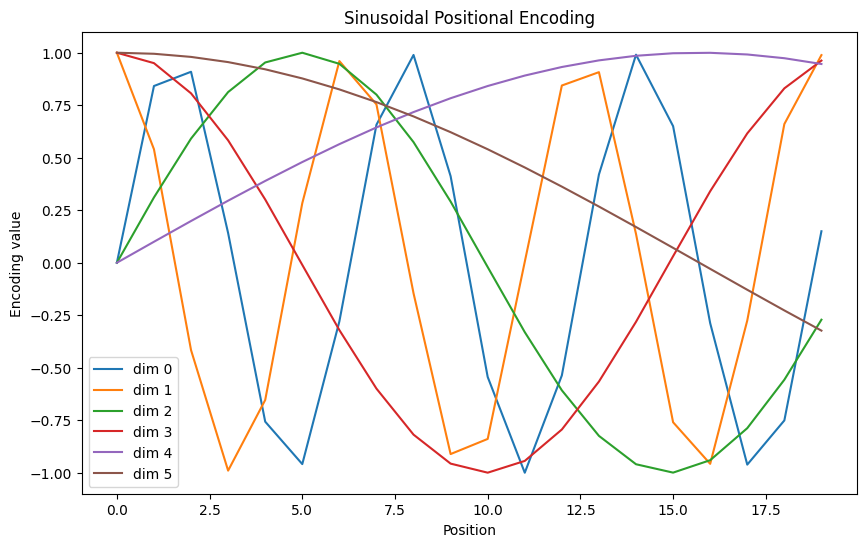

In [95]:
import matplotlib.pyplot as plt

pe = model.position_encoding.pe[0].cpu()

plt.figure(figsize=(10, 6))
for i in range(6):  # plot first 6 dimensions
    plt.plot(pe[:20, i], label=f"dim {i}")

plt.xlabel("Position")
plt.ylabel("Encoding value")
plt.title("Sinusoidal Positional Encoding")
plt.legend()
plt.show()

# Self-attention module

In [54]:
class SelfAttention(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.d_model = d_model

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor):

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_model)
        attn_weights = torch.softmax(scores, dim=-1)
        output = attn_weights @ V

        return output, attn_weights, Q, K, V

# self-attention layer

In [55]:
self_attention = SelfAttention(d_model=d_model).to(device)

# Running self-attention on the positional-encoded output

In [56]:
attn_output, attn_weights, Q, K, V = self_attention(output)

print("Attention output shape:", attn_output.shape)
print("Attention weights shape:", attn_weights.shape)
print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Attention output shape: torch.Size([2, 6, 16])
Attention weights shape: torch.Size([2, 6, 6])
Q shape: torch.Size([2, 6, 16])
K shape: torch.Size([2, 6, 16])
V shape: torch.Size([2, 6, 16])


# Inspecting attention weights for the first sentence

In [57]:
print("Attention weights for sample 0:")
print(attn_weights[0])

Attention weights for sample 0:
tensor([[0.1595, 0.1504, 0.2040, 0.1806, 0.1362, 0.1693],
        [0.1007, 0.1142, 0.1927, 0.2277, 0.1171, 0.2476],
        [0.1206, 0.1799, 0.1955, 0.2178, 0.1259, 0.1603],
        [0.0690, 0.2247, 0.2168, 0.2351, 0.0621, 0.1923],
        [0.1395, 0.1167, 0.3312, 0.1460, 0.0916, 0.1750],
        [0.0829, 0.2037, 0.1556, 0.2416, 0.1335, 0.1826]],
       grad_fn=<SelectBackward0>)


# Verifying each row sums to 1

In [58]:
row_sums = attn_weights[0].sum(dim=-1)
print("Row sums of attention weights (sample 0):")
print(row_sums)

Row sums of attention weights (sample 0):
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


# Inspect one token's attention distribution

In [59]:
token_index = 0

print(f"Attention distribution for token {token_index} in sample 0:")
print(attn_weights[0, token_index])

Attention distribution for token 0 in sample 0:
tensor([0.1595, 0.1504, 0.2040, 0.1806, 0.1362, 0.1693],
       grad_fn=<SelectBackward0>)


# Visualizing attention weights

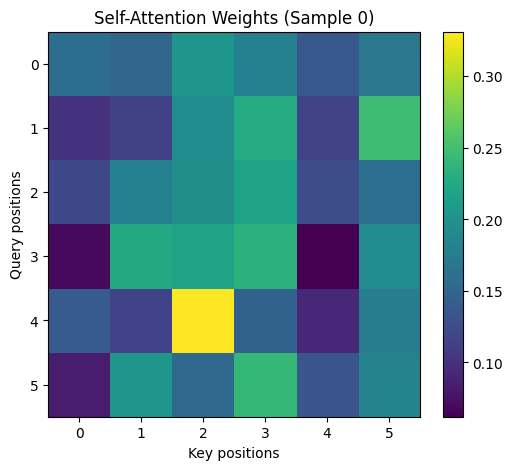

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(attn_weights[0].detach().cpu(), aspect="auto")
plt.colorbar()
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.title("Self-Attention Weights (Sample 0)")
plt.show()

# inspecting raw attention scores before softmax

In [61]:
with torch.no_grad():
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_model)

print("Raw attention scores for sample 0:")
print(scores[0])

Raw attention scores for sample 0:
tensor([[ 0.0253, -0.0332,  0.2712,  0.1496, -0.1325,  0.0847],
        [-0.3111, -0.1853,  0.3383,  0.5052, -0.1600,  0.5887],
        [-0.1443,  0.2557,  0.3390,  0.4466, -0.1015,  0.1406],
        [-0.7626,  0.4183,  0.3828,  0.4640, -0.8677,  0.2631],
        [-0.9494, -1.1279, -0.0844, -0.9033, -1.3693, -0.7222],
        [-0.5623,  0.3365,  0.0670,  0.5071, -0.0862,  0.2269]])


# Multi-head attention module

In [62]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()

        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads")

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor):

        B, T, C = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)


        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        # scaled dot-product attention
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.head_dim)
        attn_weights = torch.softmax(scores, dim=-1)
        head_outputs = attn_weights @ V

        # combine heads
        head_outputs = head_outputs.transpose(1, 2).contiguous()
        head_outputs = head_outputs.view(B, T, C)

        output = self.W_o(head_outputs)

        return output, attn_weights

# Creating multi-head attention layer

In [63]:
num_heads = 4
multi_head_attention = MultiHeadAttention(d_model=d_model, num_heads=num_heads).to(device)

mha_output, mha_weights = multi_head_attention(output)

print("Multi-head attention output shape:", mha_output.shape)
print("Multi-head attention weights shape:", mha_weights.shape)

Multi-head attention output shape: torch.Size([2, 6, 16])
Multi-head attention weights shape: torch.Size([2, 4, 6, 6])


# Inspecting one head’s attention matrix

In [64]:
head_index = 0

print(f"Attention weights for sample 0, head {head_index}:")
print(mha_weights[0, head_index])

Attention weights for sample 0, head 0:
tensor([[0.2377, 0.0605, 0.1374, 0.1108, 0.2971, 0.1565],
        [0.3743, 0.0441, 0.1239, 0.0908, 0.1808, 0.1861],
        [0.2553, 0.1394, 0.1626, 0.1446, 0.0938, 0.2044],
        [0.2552, 0.0611, 0.1700, 0.1088, 0.2046, 0.2002],
        [0.1692, 0.1329, 0.2296, 0.1411, 0.1462, 0.1809],
        [0.1697, 0.1418, 0.2459, 0.1390, 0.1054, 0.1982]],
       grad_fn=<SelectBackward0>)


# Visualizing one head

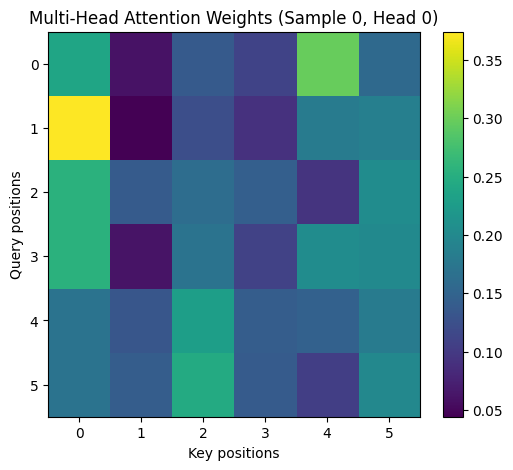

In [65]:
plt.figure(figsize=(6, 5))
plt.imshow(mha_weights[0, 0].detach().cpu(), aspect="auto")
plt.colorbar()
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.title("Multi-Head Attention Weights (Sample 0, Head 0)")
plt.show()

# Compare multiple heads

In [66]:
for h in range(num_heads):
    print(f"\nHead {h} attention weights (sample 0):")
    print(mha_weights[0, h])


Head 0 attention weights (sample 0):
tensor([[0.2377, 0.0605, 0.1374, 0.1108, 0.2971, 0.1565],
        [0.3743, 0.0441, 0.1239, 0.0908, 0.1808, 0.1861],
        [0.2553, 0.1394, 0.1626, 0.1446, 0.0938, 0.2044],
        [0.2552, 0.0611, 0.1700, 0.1088, 0.2046, 0.2002],
        [0.1692, 0.1329, 0.2296, 0.1411, 0.1462, 0.1809],
        [0.1697, 0.1418, 0.2459, 0.1390, 0.1054, 0.1982]],
       grad_fn=<SelectBackward0>)

Head 1 attention weights (sample 0):
tensor([[0.0965, 0.2350, 0.0678, 0.1591, 0.1683, 0.2733],
        [0.1387, 0.2650, 0.1405, 0.1573, 0.1393, 0.1593],
        [0.2061, 0.0743, 0.2010, 0.1733, 0.1975, 0.1478],
        [0.1407, 0.2605, 0.1682, 0.1288, 0.1294, 0.1724],
        [0.0698, 0.5248, 0.0574, 0.1140, 0.0875, 0.1465],
        [0.1540, 0.0712, 0.1006, 0.1869, 0.2450, 0.2422]],
       grad_fn=<SelectBackward0>)

Head 2 attention weights (sample 0):
tensor([[0.2222, 0.1145, 0.1481, 0.1414, 0.1404, 0.2334],
        [0.2440, 0.1042, 0.2441, 0.1877, 0.1099, 0.1101],
    

# Feed-forward neural network

In [67]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

d_ff = 64
ffn = FeedForward(d_model=d_model, d_ff=d_ff).to(device)

ffn_output = ffn(mha_output)

print("FFN output shape:", ffn_output.shape)

FFN output shape: torch.Size([2, 6, 16])


# Add & Norm block

In [68]:
class AddNorm(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.ln = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, sublayer_output: torch.Tensor) -> torch.Tensor:
        return self.ln(x + sublayer_output)

# Create AddNorm layers

In [69]:
add_norm_1 = AddNorm(d_model).to(device)
add_norm_2 = AddNorm(d_model).to(device)

# Apply residual + layer norm after MHA

In [70]:
x1 = add_norm_1(output, mha_output)

print("After first AddNorm shape:", x1.shape)

After first AddNorm shape: torch.Size([2, 6, 16])


# Apply FFN, then residual + layer norm again

In [71]:
ffn_output_2 = ffn(x1)
x2 = add_norm_2(x1, ffn_output_2)

print("After second AddNorm shape:", x2.shape)

After second AddNorm shape: torch.Size([2, 6, 16])


# Full Transformer block

In [72]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.add_norm_1 = AddNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff)
        self.add_norm_2 = AddNorm(d_model)

    def forward(self, x: torch.Tensor):
        mha_output, attn_weights = self.mha(x)
        x = self.add_norm_1(x, mha_output)

        ffn_output = self.ffn(x)
        x = self.add_norm_2(x, ffn_output)

        return x, attn_weights

# Create Transformer block

In [73]:
transformer_block = TransformerBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff).to(device)

# Run Transformer block

In [74]:
block_output, block_attn_weights = transformer_block(output)

print("Transformer block output shape:", block_output.shape)
print("Transformer block attention shape:", block_attn_weights.shape)

Transformer block output shape: torch.Size([2, 6, 16])
Transformer block attention shape: torch.Size([2, 4, 6, 6])


# self-attention module

In [75]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, max_len: int):
        super().__init__()

        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads")

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        mask = torch.tril(torch.ones(max_len, max_len))
        self.register_buffer("mask", mask)

    def forward(self, x: torch.Tensor):
        B, T, C = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.head_dim)

        causal_mask = self.mask[:T, :T]
        scores = scores.masked_fill(causal_mask == 0, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)
        head_outputs = attn_weights @ V

        head_outputs = head_outputs.transpose(1, 2).contiguous()
        head_outputs = head_outputs.view(B, T, C)

        output = self.W_o(head_outputs)

        return output, attn_weights

#causal attention layer

In [76]:
causal_attention = CausalSelfAttention(
    d_model=d_model,
    num_heads=num_heads,
    max_len=max_len
).to(device)

# Run causal attention

In [77]:
causal_output, causal_weights = causal_attention(output)

print("Causal attention output shape:", causal_output.shape)
print("Causal attention weights shape:", causal_weights.shape)

Causal attention output shape: torch.Size([2, 6, 16])
Causal attention weights shape: torch.Size([2, 4, 6, 6])


# Inspect one head’s masked attention matrix

In [78]:
print("Causal attention weights for sample 0, head 0:")
print(causal_weights[0, 0])

Causal attention weights for sample 0, head 0:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2323, 0.7677, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3684, 0.3337, 0.2978, 0.0000, 0.0000, 0.0000],
        [0.1514, 0.2095, 0.4821, 0.1569, 0.0000, 0.0000],
        [0.0824, 0.1995, 0.6176, 0.0508, 0.0496, 0.0000],
        [0.1088, 0.1130, 0.3114, 0.1237, 0.0925, 0.2506]],
       grad_fn=<SelectBackward0>)


# Visualizing the causal mask behavior

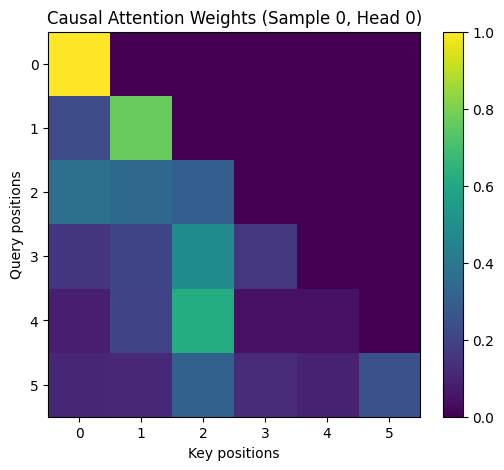

In [79]:
plt.figure(figsize=(6, 5))
plt.imshow(causal_weights[0, 0].detach().cpu(), aspect="auto")
plt.colorbar()
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.title("Causal Attention Weights (Sample 0, Head 0)")
plt.show()

# Print the actual mask

In [80]:
print("Causal mask used for sequence length =", input_ids.size(1))
print(causal_attention.mask[:input_ids.size(1), :input_ids.size(1)])

Causal mask used for sequence length = 6
tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


# Transformer block

In [81]:
class GPTBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, max_len: int):
        super().__init__()
        self.attn = CausalSelfAttention(d_model, num_heads, max_len)
        self.add_norm_1 = AddNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff)
        self.add_norm_2 = AddNorm(d_model)

    def forward(self, x: torch.Tensor):
        attn_output, attn_weights = self.attn(x)
        x = self.add_norm_1(x, attn_output)

        ffn_output = self.ffn(x)
        x = self.add_norm_2(x, ffn_output)

        return x, attn_weights

# GPT block

In [82]:
gpt_block = GPTBlock(
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    max_len=max_len
).to(device)
gpt_output, gpt_attn_weights = gpt_block(output)

print("GPT block output shape:", gpt_output.shape)
print("GPT block attention shape:", gpt_attn_weights.shape)

GPT block output shape: torch.Size([2, 6, 16])
GPT block attention shape: torch.Size([2, 4, 6, 6])


# Tiny GPT model

In [83]:
class TinyGPT(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, num_heads: int, d_ff: int, max_len: int):
        super().__init__()
        self.embedding_block = InputEmbeddingBlock(vocab_size, d_model, max_len)
        self.block = GPTBlock(d_model, num_heads, d_ff, max_len)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids: torch.Tensor):
        x = self.embedding_block(input_ids)
        x, attn_weights = self.block(x)
        logits = self.lm_head(x)
        return logits, attn_weights

tiny_gpt = TinyGPT(
vocab_size=vocab_size,
d_model=d_model,
num_heads=num_heads,
d_ff=d_ff,
max_len=max_len
).to(device)

logits, final_attn_weights = tiny_gpt(input_ids)

print("Logits shape:", logits.shape)
print("Attention weights shape:", final_attn_weights.shape)

# Convert logits to probabilities

probs = torch.softmax(logits, dim=-1)

print("Probabilities shape:", probs.shape)
print("Probability distribution for first token in first sentence:")
print(probs[0, 0])
print("Sum:", probs[0, 0].sum())

Logits shape: torch.Size([2, 6, 100])
Attention weights shape: torch.Size([2, 4, 6, 6])
Probabilities shape: torch.Size([2, 6, 100])
Probability distribution for first token in first sentence:
tensor([0.0095, 0.0064, 0.0078, 0.0040, 0.0140, 0.0088, 0.0070, 0.0036, 0.0049,
        0.0164, 0.0075, 0.0056, 0.0078, 0.0176, 0.0112, 0.0093, 0.0084, 0.0104,
        0.0044, 0.0070, 0.0120, 0.0254, 0.0055, 0.0218, 0.0209, 0.0078, 0.0086,
        0.0079, 0.0109, 0.0059, 0.0071, 0.0119, 0.0097, 0.0043, 0.0063, 0.0124,
        0.0166, 0.0074, 0.0033, 0.0118, 0.0050, 0.0023, 0.0167, 0.0119, 0.0146,
        0.0064, 0.0096, 0.0069, 0.0103, 0.0125, 0.0033, 0.0097, 0.0239, 0.0085,
        0.0151, 0.0122, 0.0254, 0.0065, 0.0029, 0.0091, 0.0066, 0.0047, 0.0095,
        0.0047, 0.0056, 0.0073, 0.0121, 0.0063, 0.0134, 0.0047, 0.0058, 0.0073,
        0.0216, 0.0081, 0.0204, 0.0047, 0.0063, 0.0047, 0.0128, 0.0218, 0.0068,
        0.0074, 0.0099, 0.0123, 0.0080, 0.0100, 0.0081, 0.0070, 0.0140, 0.0046,
       

# predicted next tokens

In [84]:
predicted_tokens = torch.argmax(logits, dim=-1)

print("Predicted token IDs:")
print(predicted_tokens)


targets = input_ids.clone()
targets[:, :-1] = input_ids[:, 1:]
targets[:, -1] = 0

print("Input IDs:")
print(input_ids)

print("\nTargets for next-token prediction:")
print(targets)

# cross-entropy loss
loss_fn = nn.CrossEntropyLoss()

B, T, V = logits.shape
loss = loss_fn(logits.view(B * T, V), targets.view(B * T))

print("Cross-entropy loss:", loss.item())

Predicted token IDs:
tensor([[56, 90, 83, 41, 81, 64],
        [79, 15, 36, 62, 17, 41]])
Input IDs:
tensor([[1, 5, 8, 2, 9, 4],
        [3, 7, 1, 0, 6, 2]])

Targets for next-token prediction:
tensor([[5, 8, 2, 9, 4, 0],
        [7, 1, 0, 6, 2, 0]])
Cross-entropy loss: 4.8173508644104


# training step with Adam


In [85]:
optimizer = torch.optim.Adam(tiny_gpt.parameters(), lr=1e-3)

optimizer.zero_grad()
logits, _ = tiny_gpt(input_ids)

B, T, V = logits.shape
loss = loss_fn(logits.view(B * T, V), targets.view(B * T))

loss.backward()
optimizer.step()

print("Completed one training step.")
print("Loss:", loss.item())

Completed one training step.
Loss: 4.8173508644104


# Stacked GPT model

In [86]:
class StackedGPT(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        num_heads: int,
        d_ff: int,
        max_len: int,
        num_layers: int
    ):
        super().__init__()

        self.embedding_block = InputEmbeddingBlock(vocab_size, d_model, max_len)

        self.blocks = nn.ModuleList([
            GPTBlock(d_model, num_heads, d_ff, max_len)
            for _ in range(num_layers)
        ])

        self.final_ln = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids: torch.Tensor):
        x = self.embedding_block(input_ids)
        all_attn_weights = []

        for block in self.blocks:
            x, attn_weights = block(x)
            all_attn_weights.append(attn_weights)

        x = self.final_ln(x)
        logits = self.lm_head(x)

        return logits, all_attn_weights


# Create stacked model
num_layers = 2

stacked_gpt = StackedGPT(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    max_len=max_len,
    num_layers=num_layers
).to(device)

# Test forward pass
logits, all_attn_weights = stacked_gpt(input_ids)

print("Logits shape:", logits.shape)
print("Number of layers of attention weights:", len(all_attn_weights))
print("Attention weight shape from layer 0:", all_attn_weights[0].shape)

Logits shape: torch.Size([2, 6, 100])
Number of layers of attention weights: 2
Attention weight shape from layer 0: torch.Size([2, 4, 6, 6])


# Loss, optimizer, and a small training loop

In [87]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(stacked_gpt.parameters(), lr=1e-3)

# next-token targets
targets = input_ids.clone()
targets[:, :-1] = input_ids[:, 1:]
targets[:, -1] = 0

print("Input IDs:")
print(input_ids)
print("\nTargets:")
print(targets)

# small training loop
num_steps = 20

for step in range(num_steps):
    stacked_gpt.train()
    optimizer.zero_grad()

    logits, _ = stacked_gpt(input_ids)
    B, T, V = logits.shape

    loss = loss_fn(logits.view(B * T, V), targets.view(B * T))
    loss.backward()
    optimizer.step()

    if step % 5 == 0 or step == num_steps - 1:
        print(f"Step {step:2d} | Loss: {loss.item():.4f}")

Input IDs:
tensor([[1, 5, 8, 2, 9, 4],
        [3, 7, 1, 0, 6, 2]])

Targets:
tensor([[5, 8, 2, 9, 4, 0],
        [7, 1, 0, 6, 2, 0]])
Step  0 | Loss: 4.8018
Step  5 | Loss: 4.3650
Step 10 | Loss: 4.0036
Step 15 | Loss: 3.7115
Step 19 | Loss: 3.5154


# Greedy text generation

In [88]:
def generate(model, input_ids, max_new_tokens, max_len):
    model.eval()

    generated = input_ids.clone()

    for _ in range(max_new_tokens):

        idx_cond = generated[:, -max_len:]

        with torch.no_grad():
            logits, _ = model(idx_cond)


        next_token_logits = logits[:, -1, :]
        next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)

        generated = torch.cat([generated, next_token], dim=1)

    return generated



start_tokens = torch.tensor([[1, 5, 8]], device=device)

generated_tokens = generate(
    model=stacked_gpt,
    input_ids=start_tokens,
    max_new_tokens=5,
    max_len=max_len
)

print("Start tokens:")
print(start_tokens)

print("\nGenerated tokens:")
print(generated_tokens)

Start tokens:
tensor([[1, 5, 8]])

Generated tokens:
tensor([[1, 5, 8, 2, 0, 0, 0, 0]])


# Tiny text dataset + character tokenizer

In [89]:
text = """
attention is all you need
transformers use positional encoding
positional encoding gives order to tokens
self attention lets tokens communicate
language models predict the next token
"""

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[ch] for ch in s]

def decode(ids):
    return "".join([itos[i] for i in ids])

data = torch.tensor(encode(text), dtype=torch.long, device=device)

print("Vocabulary size:", vocab_size)
print("Characters:", chars)
print("Dataset length:", len(data))
print("Encoded sample:", data[:30])
print("Decoded sample:", decode(data[:30].tolist()))

Vocabulary size: 23
Characters: ['\n', ' ', 'a', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'x', 'y']
Dataset length: 184
Encoded sample: tensor([ 0,  2, 18, 18,  5, 13, 18,  9, 14, 13,  1,  9, 17,  1,  2, 11, 11,  1,
        22, 14, 19,  1, 13,  5,  5,  4,  0, 18, 16,  2])
Decoded sample: 
attention is all you need
tra


# Batch creator

In [90]:
block_size = 32
batch_size = 8

def get_batch():
    ix = torch.randint(0, len(data) - block_size - 1, (batch_size,), device=device)

    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])

    return x, y

xb, yb = get_batch()

print("Input batch shape:", xb.shape)
print("Target batch shape:", yb.shape)

print("\nFirst input example:")
print(decode(xb[0].tolist()))

print("\nFirst target example:")
print(decode(yb[0].tolist()))

Input batch shape: torch.Size([8, 32])
Target batch shape: torch.Size([8, 32])

First input example:
ng gives order to tokens
self at

First target example:
g gives order to tokens
self att


# Creating a new model for real text

In [91]:
d_model = 64
num_heads = 4
d_ff = 256
max_len = block_size
num_layers = 2

text_gpt = StackedGPT(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    max_len=max_len,
    num_layers=num_layers
).to(device)

optimizer = torch.optim.Adam(text_gpt.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

print("Text GPT model created.")
print("Vocabulary size:", vocab_size)
print("Block size:", block_size)

Text GPT model created.
Vocabulary size: 23
Block size: 32


# Training on the tiny text

In [92]:
num_steps = 300

for step in range(num_steps):
    xb, yb = get_batch()

    logits, _ = text_gpt(xb)
    B, T, V = logits.shape

    loss = loss_fn(logits.view(B * T, V), yb.view(B * T))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0 or step == num_steps - 1:
        print(f"Step {step:3d} | Loss: {loss.item():.4f}")

Step   0 | Loss: 3.2666
Step  50 | Loss: 1.7680
Step 100 | Loss: 0.7569
Step 150 | Loss: 0.3344
Step 200 | Loss: 0.1522
Step 250 | Loss: 0.1414
Step 299 | Loss: 0.1131


# Generate text

In [94]:
def generate_text(model, start_text, max_new_chars=100):
    model.eval()

    input_ids = torch.tensor([encode(start_text)], dtype=torch.long, device=device)

    generated = input_ids.clone()

    for _ in range(max_new_chars):
        idx_cond = generated[:, -block_size:]

        with torch.no_grad():
            logits, _ = model(idx_cond)

        next_logits = logits[:, -1, :]
        probs = torch.softmax(next_logits, dim=-1)

        next_id = torch.multinomial(probs, num_samples=1)
        generated = torch.cat([generated, next_id], dim=1)

    return decode(generated[0].tolist())

print(generate_text(text_gpt, "attention", max_new_chars=100))

attention lets tokens communicateicodict thext poke
lanentioncodit tiokencommmunicate
language models predict
